In [ ]:
import sys, os
from glob import glob
sys.path.append(os.path.join('../') ) # rel. dir. to find toolbox 

import numpy as np
import pandas as pd
from scipy import io, signal
import librosa.feature, librosa.display
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
# plt.style.use('dark_background') # annotations color to "snow"
# plt.style.use('seaborn-v0_8-pastel') # annotations color to "gray"

In [63]:
stim_dir = './../experiment_reports/stim_metadata_384kHz'

In [ ]:
condition_labels = {#'echo_pulse':'echo. pulse',
                    'echo_seq': 'echolocation seq.',                        
                    # 'nat_syll': 'nat. syll.',                                        
                    'distress_seq': 'distress seq.',
                    'isolation_1':'pup isolation seq.'}   
stim_files = glob(stim_dir+"/*.wav")
print(stim_files)
get_files = [s for s in stim_files if s.rsplit('/')[-1].removesuffix('.wav') in condition_labels.keys()]
get_files

['./../experiment_reports/stim_metadata_384kHz/echo_pulse.wav', './../experiment_reports/stim_metadata_384kHz/nat_syll.wav', './../experiment_reports/stim_metadata_384kHz/isolation_1.wav', './../experiment_reports/stim_metadata_384kHz/distress_seq.wav', './../experiment_reports/stim_metadata_384kHz/echo_seq.wav']


['./../experiment_reports/stim_metadata_384kHz/isolation_1.wav',
 './../experiment_reports/stim_metadata_384kHz/distress_seq.wav',
 './../experiment_reports/stim_metadata_384kHz/echo_seq.wav']

In [69]:
for f in get_files[0:1]:
    sr, audio = io.wavfile.read(f)

audio

array([ 0,  0,  0, ..., 26, 21, -5], dtype=int16)

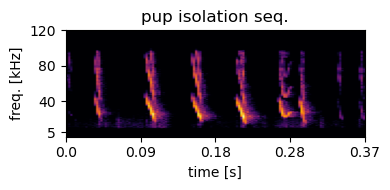

In [ ]:
cond = f.rsplit('/')[-1].removesuffix('.wav')

# plot limits
ymin = 5e3
ymax = 120e3
xmin = 0
xmax = len(audio)/sr
yn=5

n_fft = 2048*2
# stft_x = librosa.stft(audio.astype(float), n_fft=n_fft, win_length=n_fft//2, hop_length=n_fft//4)  
# stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max, top_db=10) # equivalent to: librosa.power_to_db(np.abs(stft)**2, ref=ref**2, amin=amin**2, top_db=top_db),

stft_f, stft_t, stft_x = signal.stft(audio.astype(float), fs=sr, nfft=n_fft, nperseg=n_fft//2, noverlap=n_fft//4, scaling='spectrum')
stft_db = librosa.amplitude_to_db(np.abs(stft_x)**2, ref=np.max, top_db=140) # 100 for distress; 150 for echo; 140 pup 


fig, axes = plt.subplots(figsize=(4,2))
ax = axes
# im1 = librosa.display.specshow(stft_db,
#                                sr=sr, 
#                                y_axis='linear', 
#                                ax=ax, cmap='inferno')

# im1 = ax.imshow(stft_db, aspect='auto', cmap="inferno", 
#                extent=[xmin, xmax, stft_f[0], stft_f[-1]], 
#                origin='lower')

freq_mask = stft_f <= ymax
im1 = ax.imshow(stft_db[freq_mask], aspect='auto', cmap="inferno",
                extent=[xmin, xmax, stft_f[freq_mask][0], stft_f[freq_mask][-1]],
                origin='lower')

ax.set_xticks(np.linspace(xmin,xmax,5), np.round(np.linspace(xmin,xmax,5),2))
ax.set_xlabel('time [s]')
ax.set_ylim(ymin, ymax)

ax.set_yticks(np.array([5,40,80,120])*1e3, [5,40,80,120])
ax.set_ylabel('freq. [kHz]')

ax.set_title(condition_labels[cond])
ax.axis('tight')

# fig.colorbar(im1, ax=ax, format="%+2.0f dB")
fig.tight_layout()
for ext in ['.png','.pdf']:
    fig.savefig(stim_dir+'/figures/'+cond+ext, transparent=True, dpi=300, bbox_inches='tight')

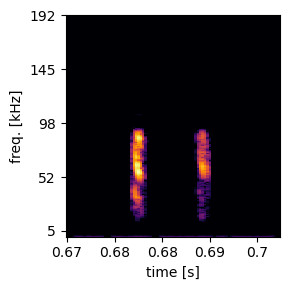

In [230]:
fig, axes = plt.subplots(figsize=(3,3))
ax = axes
t_ax = np.linspace(0,audio.shape[-1]/sr,stft.shape[1])
idx_range = np.intersect1d(np.where(t_ax>0.67), np.where(t_ax<0.7))
im1 = librosa.display.specshow(stft_db[:,idx_range],
                               sr=sr,
                               y_axis='linear', 
                               ax=ax, cmap='inferno')

# marker_10m = np.argwhere(np.linspace(0,audio.shape[-1]/sr,stft.shape[1])>0.01)[0][0]
# ax.set_xticks(np.linspace(0,stft.shape[1],stft.shape[1],endpoint=True)[np.array([0, stft.shape[1]-10])], 
#               np.round(np.linspace(0,audio.shape[-1]/sr,stft.shape[1]),2)[np.array([0, stft.shape[1]-10])])

ax.set_xticks(np.arange(0,stft_db[:,idx_range].shape[1])[::20], 
              np.round(np.linspace(0,audio.shape[-1]/sr,stft.shape[1]),2)[idx_range][::20])
ax.set_xlabel('time [s]')
ax.set_ylim(ymin, ymax)
ax.set_yticks(np.linspace(ymin,ymax,yn),np.round(np.linspace(ymin,ymax,yn)/1e3).astype(int))
ax.set_ylabel('freq. [kHz]')
ax.axis('tight')
# fig.colorbar(im1, ax=ax, format="%+2.0f dB")
fig.tight_layout()
fig.savefig(stim_dir+'/figures/'+cond+'_exp.png', transparent=True)